## DEGs per entire unsplit dataset (all IPF lung apex/base samples)

In [1]:
# Load necessary packages
library(data.table) #for reading in data
library(tidyverse) #for visualization

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks data.table::transpose()
✖ lubridate::wday() 

In [25]:
#function for adjusting ggplot sizes later
plot_size <- function(wid, hei, res = 150) {
  options(repr.plot.width = wid, repr.plot.height = hei, repr.plot.res = res)
}

In [2]:
# Read in data
degs <- fread("260510_Stoats_DEG.csv")
emap <- fread("mart_export.txt", data.table=FALSE) #mapping table for ENSMUS-->symbol
snps <- fread("SNPgenes.csv") #SNP-associated genes from DD SNPs

In [3]:
head(degs)
head(emap)
head(snps)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000164694,322.2632,4.375902,0.16140844,27.11074,7.356646e-162,1.108279e-157
ENSG00000168453,136.0970,2.534267,0.11250693,22.52543,2.338969e-112,1.761828e-108
ENSG00000168675,572.7574,1.328462,0.06199296,21.42924,7.133943e-102,3.582428e-98
ENSG00000000971,7085.7264,2.013110,0.09583155,21.00675,5.689260e-98,2.142718e-94
ENSG00000134247,1210.4359,1.832954,0.09298080,19.71325,1.659674e-86,4.167166e-83
ENSG00000049323,3545.1604,1.856375,0.09415089,19.71702,1.540269e-86,4.167166e-83


,Gene stable ID,Gene name,Transcript stable ID
,<chr>,<chr>,<chr>
1,ENSG00000210049,MT-TF,ENST00000387314
2,ENSG00000211459,MT-RNR1,ENST00000389680
3,ENSG00000210077,MT-TV,ENST00000387342
4,ENSG00000210082,MT-RNR2,ENST00000387347
5,ENSG00000209082,MT-TL1,ENST00000386347
6,ENSG00000198888,MT-ND1,ENST00000361390


SNP ID,Gene Name
<chr>,<chr>
rs10276303,SDK1
rs10276303,CARD11
rs10276303,SDK1-AS1
rs1032466,ATL1
rs1032466,MAP4K5
rs1032466,SAV1


In [4]:
# Convert ensemb IDs to common gene symbols
geneIDs <- degs$V1
degs <- as.data.frame(degs)

gene_map <- setNames(
  emap$`Gene name`,
  emap$`Gene stable ID`
)

symbols <- gene_map[geneIDs]
symbols <- unname(symbols)

degs$V1 <- symbols

In [5]:
head(degs)
dim(degs)
dim(filter(degs, padj<0.05, abs(log2FoldChange)>2))

,V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,FNDC1,322.2632,4.375902,0.16140844,27.11074,7.356646e-162,1.108279e-157
2,HR,136.0970,2.534267,0.11250693,22.52543,2.338969e-112,1.761828e-108
3,LDLRAD4,572.7574,1.328462,0.06199296,21.42924,7.133943e-102,3.582428e-98
4,CFH,7085.7264,2.013110,0.09583155,21.00675,5.689260e-98,2.142718e-94
5,PTGFRN,1210.4359,1.832954,0.09298080,19.71325,1.659674e-86,4.167166e-83
6,LTBP1,3545.1604,1.856375,0.09415089,19.71702,1.540269e-86,4.167166e-83


[1] 15065     7

[1] 644   7

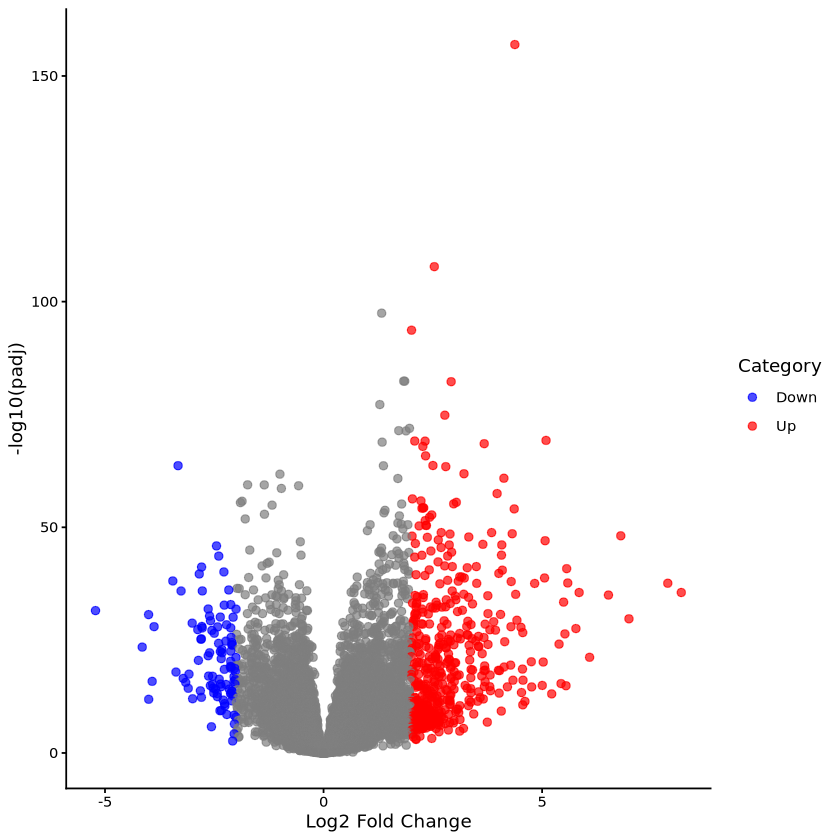

In [6]:
# Plot 1: Volcano plot, combined data (control = NDC apex/base, experimental = IPF apex/base)
ggplot(degs, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = case_when(
      padj < 0.05 & log2FoldChange > 2  ~ "Up",
      padj < 0.05 & log2FoldChange < -2 ~ "Down",
      TRUE ~ "NS")),
           alpha=0.7, size=2) +
scale_color_manual(values = c(
"Up" = "red",
"Down" = "blue",
TRUE ~ "NS")) +
theme_classic() +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="Category")

## Work with split DEGs (split by tissue type)

In [7]:
# Read in split DEGs
apex <- fread("260513_Stoats_NAvIA_DEG_Fixed.csv") #IPF apex DEGs (versus NDC apex)
base <- fread("260513_Stoats_NBvIB_DEG_Fixed.csv") #IPF base DEGs (versus NDC base)
diseaseregion <- fread("260513_Stoats_IAvIB_DEG_Fixed.csv")
healthyregion <- fread("260513_Stoats_NAvNB_DEG_Fixed.csv")

In [8]:
head(apex)
head(healthyregion)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_biotype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
FNDC1,268.5352,4.168524,0.2184942,19.07842,3.816293e-81,5.749245e-77,protein_coding
KCNE4,300.9393,2.458783,0.1493231,16.46619,6.419024e-61,3.223420e-57,protein_coding
MMP16,123.4965,3.294787,0.1999383,16.47902,5.192233e-61,3.223420e-57,protein_coding
HR,125.3527,2.337936,0.1503054,15.55457,1.481470e-54,5.579588e-51,protein_coding
CFH,7298.8874,2.092229,0.1385840,15.09719,1.689832e-51,5.091462e-48,protein_coding
LAMP5,117.8563,3.413980,0.2348557,14.53650,7.113782e-48,1.786152e-44,protein_coding


V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_biotype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DNASE1L3,423.6421,-2.763710,0.3379758,-8.177243,2.904130e-16,4.375072e-12,protein_coding
POSTN,2191.0356,-1.827556,0.2963222,-6.167461,6.939538e-10,2.613604e-06,protein_coding
CCL23,160.6848,-1.774410,0.2838470,-6.251289,4.070790e-10,2.613604e-06,protein_coding
PI3,301.6614,3.550421,0.5745251,6.179749,6.420342e-10,2.613604e-06,protein_coding
CCR7,66.2236,2.323047,0.3949246,5.882255,4.047145e-09,1.219405e-05,protein_coding
PLA1A,495.5586,-1.216066,0.2195012,-5.540133,3.022424e-08,6.504689e-05,protein_coding


In [9]:
snps$`Gene Name` %in% apex$V1 #check whether SNP-associated genes from DD are present in IPF dataset

[1]  TRUE  TRUE FALSE  TRUE  TRUE  TRUE FALSE FALSE  TRUE FALSE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE FALSE FALSE  TRUE FALSE  TRUE  TRUE FALSE  TRUE FALSE
 [25] FALSE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE
 [37]  TRUE  TRUE FALSE FALSE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE FALSE FALSE
 [49]  TRUE  TRUE FALSE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE FALSE FALSE  TRUE
 [61]  TRUE  TRUE FALSE  TRUE FALSE FALSE FALSE FALSE  TRUE FALSE  TRUE  TRUE
 [73]  TRUE  TRUE FALSE FALSE FALSE FALSE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE
 [85]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE  TRUE  TRUE FALSE
 [97]  TRUE  TRUE  TRUE FALSE  TRUE FALSE FALSE  TRUE  TRUE

### Volcano Plots

[1] 15012     8

[1] 380   8

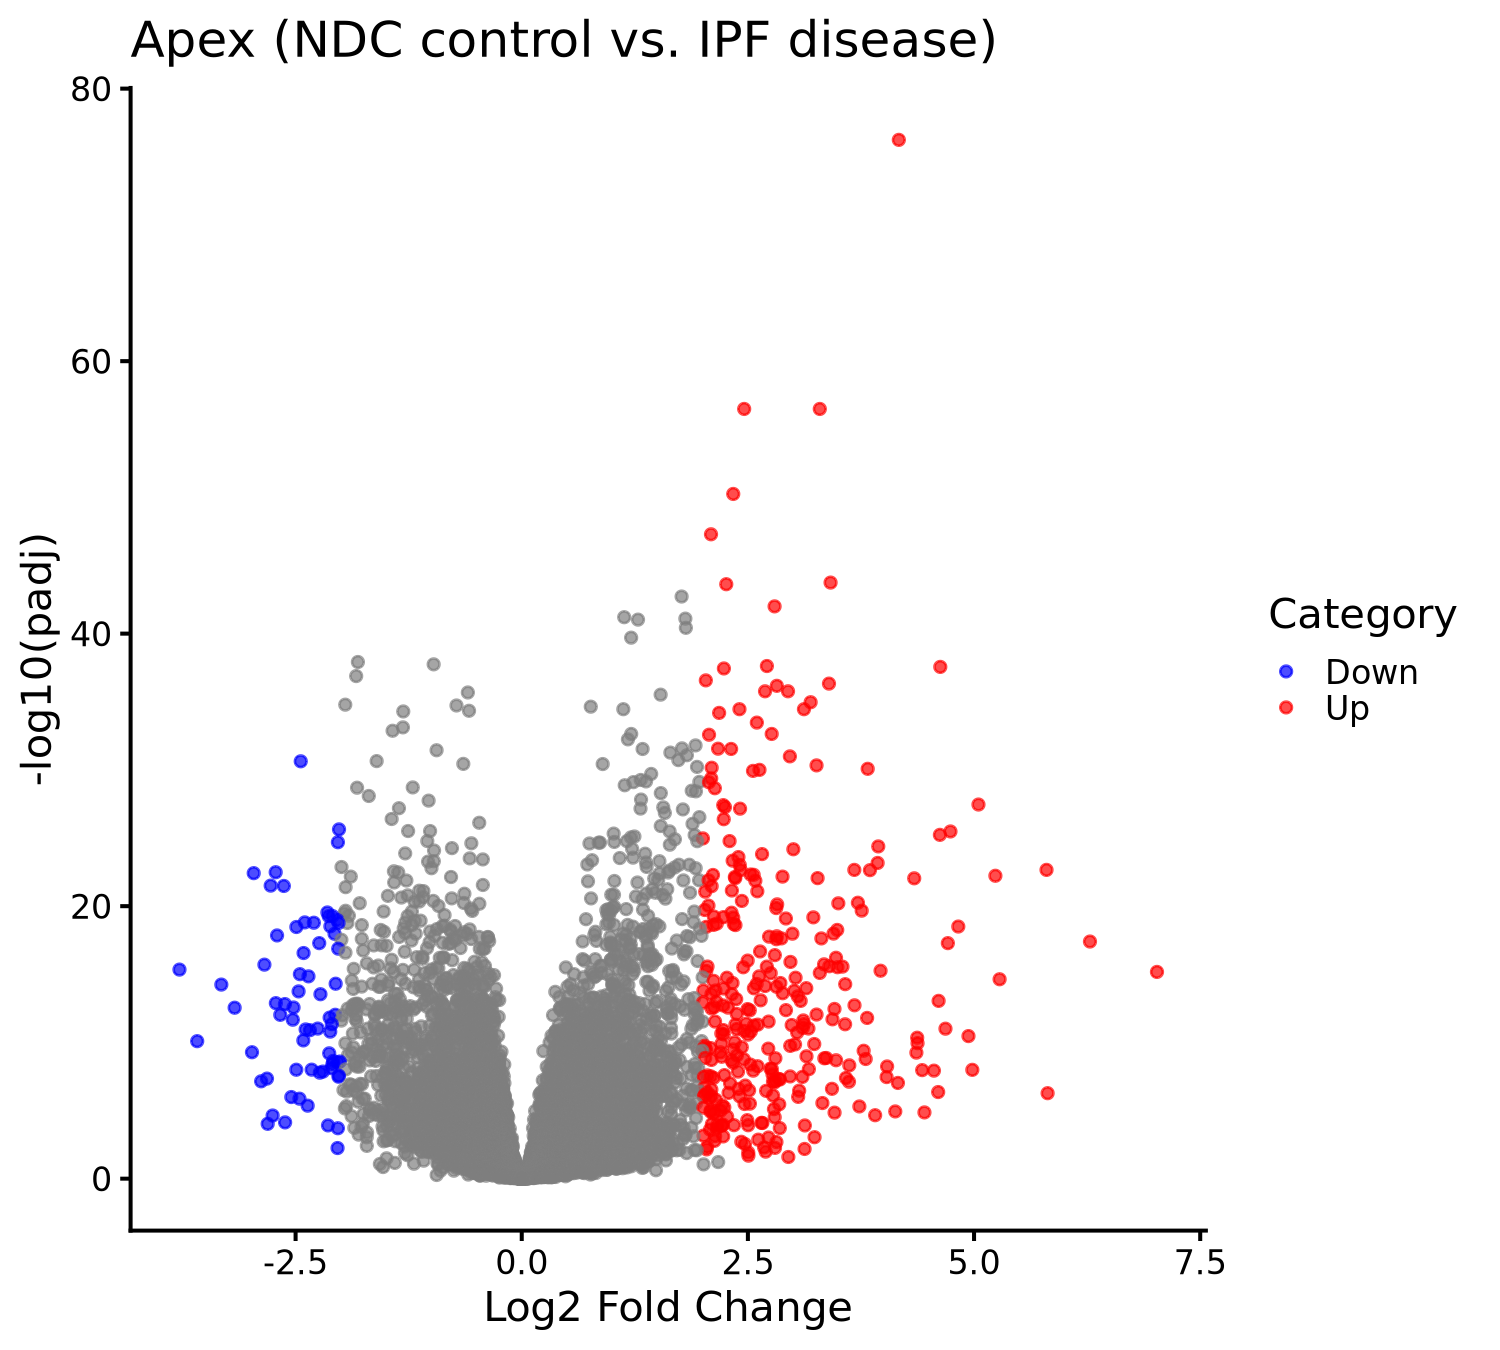

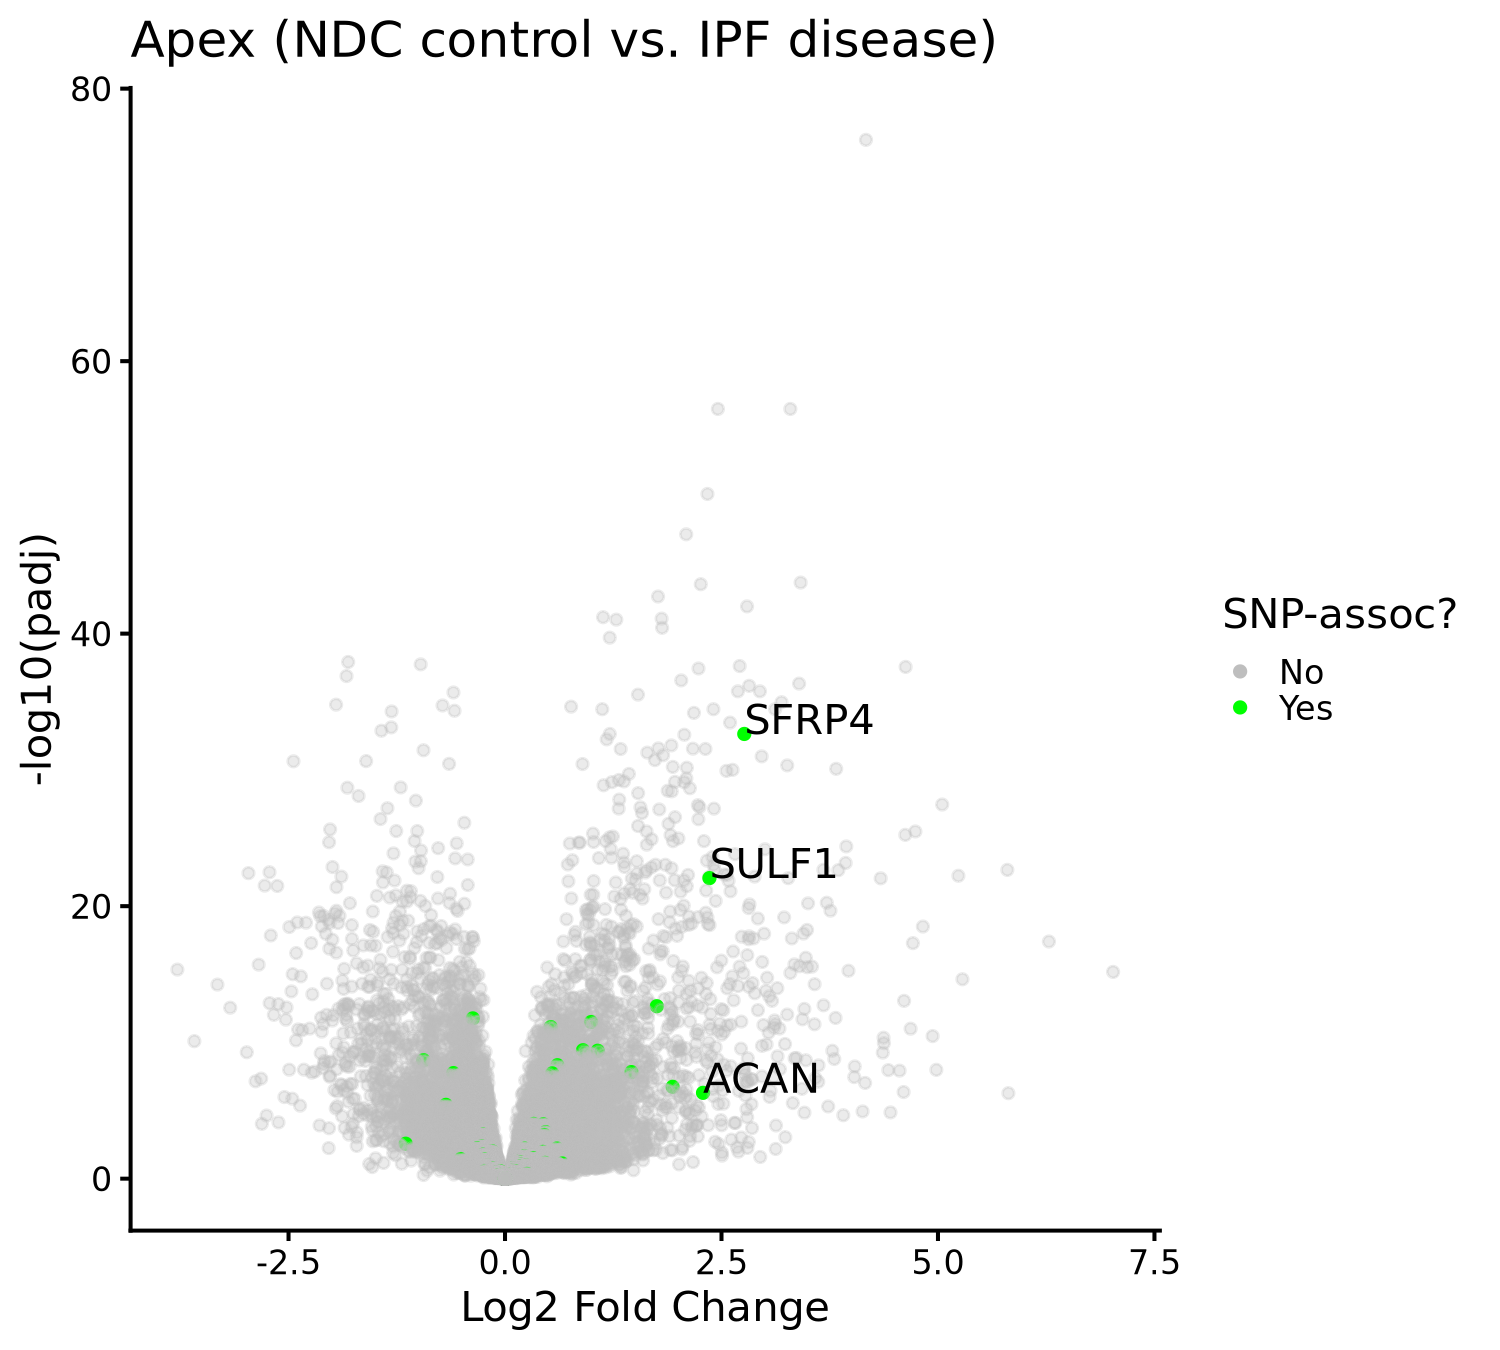

In [46]:
# All IPF apex DEGs
plot_size(wid = 10, hei = 9)
ggplot(apex, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = case_when(
      padj < 0.05 & log2FoldChange > 2  ~ "Up",
      padj < 0.05 & log2FoldChange < -2 ~ "Down",
      TRUE ~ "NS")),
           alpha=0.7, size=2) +
scale_color_manual(values = c(
"Up" = "red",
"Down" = "blue",
TRUE ~ "NS")) +
theme_classic(base_size = 20) +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="Category", title="Apex (NDC control vs. IPF disease)")

dim(apex)
dim(filter(apex, padj<0.05, abs(log2FoldChange)>2)) #number of IPF apex DEGs

# Volcano plot colored by DD SNP-associated genes
ggplot(apex, aes(x = log2FoldChange,
                 y = -log10(padj),
                 label = V1)) +
geom_point(aes(color = ifelse(V1 %in% snps$`Gene Name`, "Yes", "No"), #color point green if SNP-associated
    alpha = ifelse(V1 %in% snps$`Gene Name`, 1, 0.3)), size = 2) +
scale_color_manual(values = c("Yes" = "green", "No" = "gray")) +
scale_alpha_identity() +
geom_text(aes(label = ifelse( #add label to point if DEG and SNP-associated
    V1 %in% snps$`Gene Name` &
    padj < 0.05 &
    abs(log2FoldChange) > 2,
    as.character(V1),"")), hjust=0, vjust=0) +
theme_classic(base_size = 20) +
labs(x = "Log2 Fold Change", y = "-log10(padj)", color = "SNP-assoc?", 
     title = "Apex (NDC control vs. IPF disease)")

[1] 15012     8

[1] 881   8

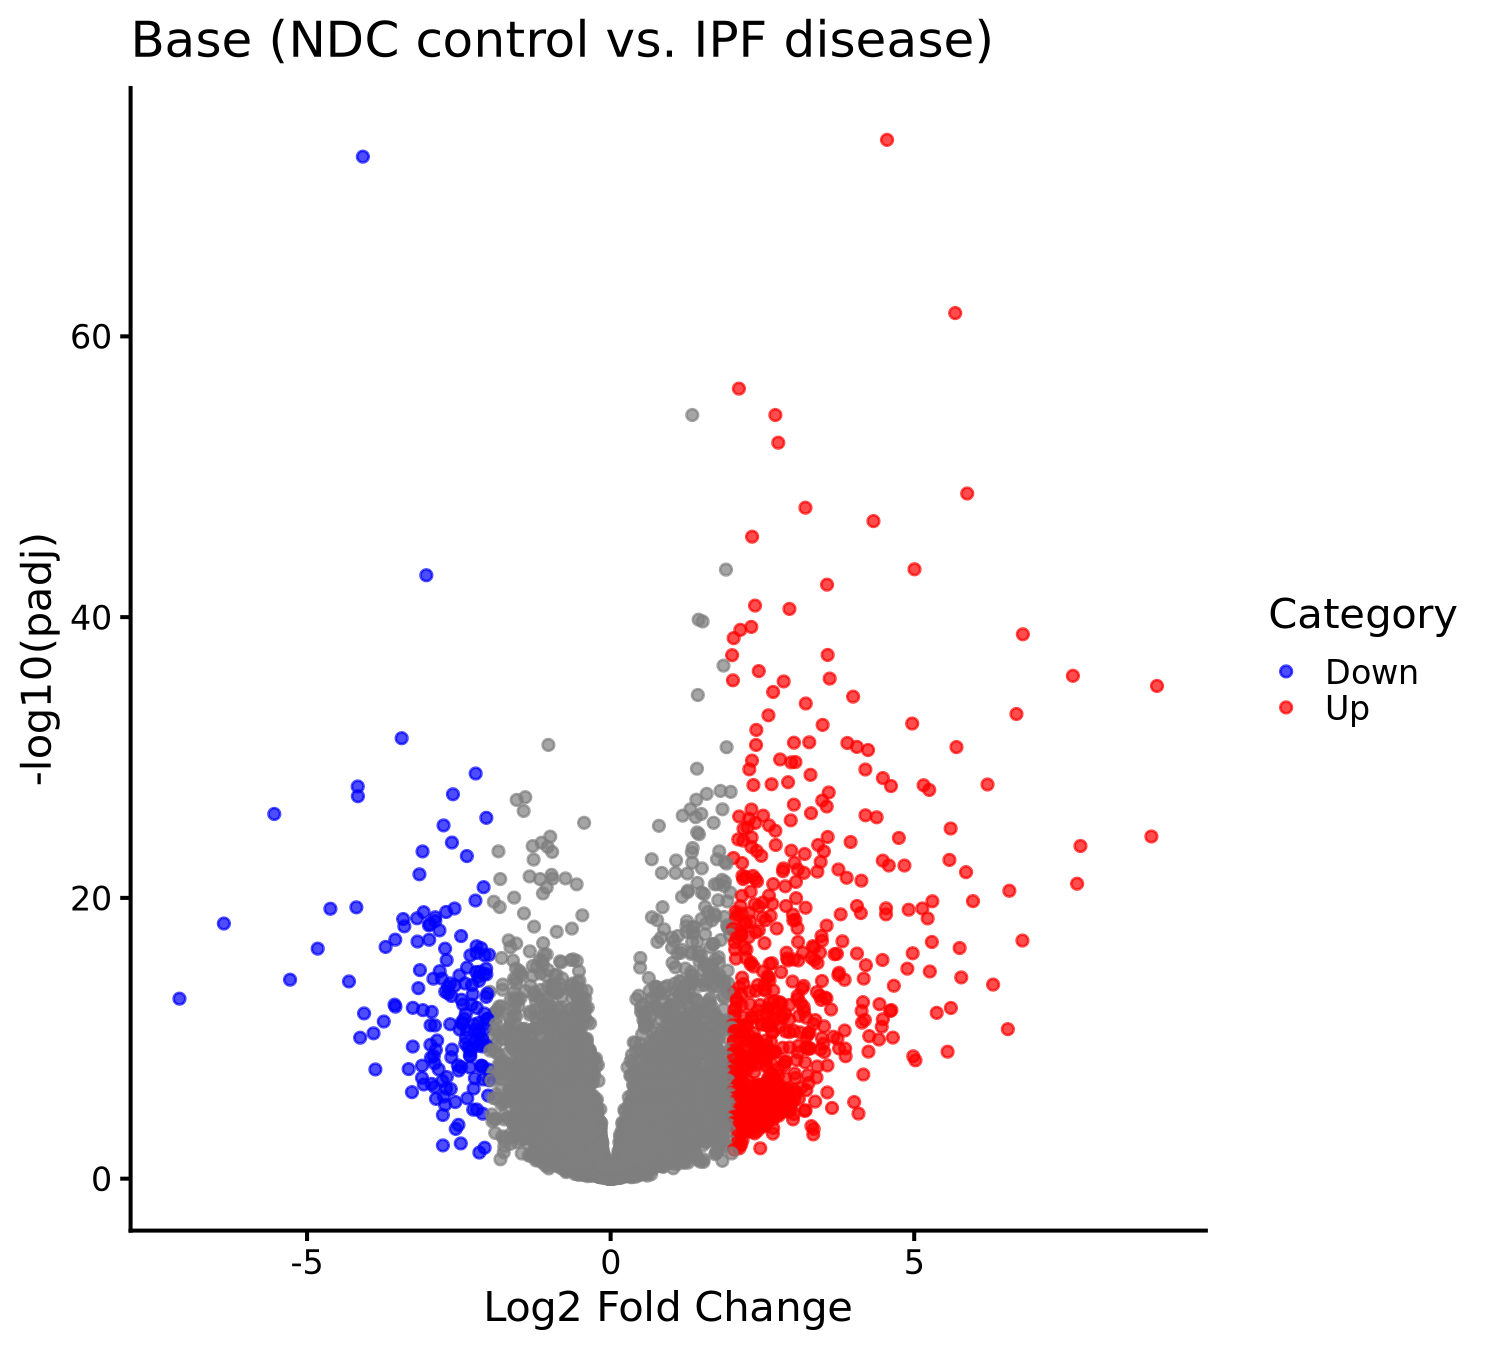

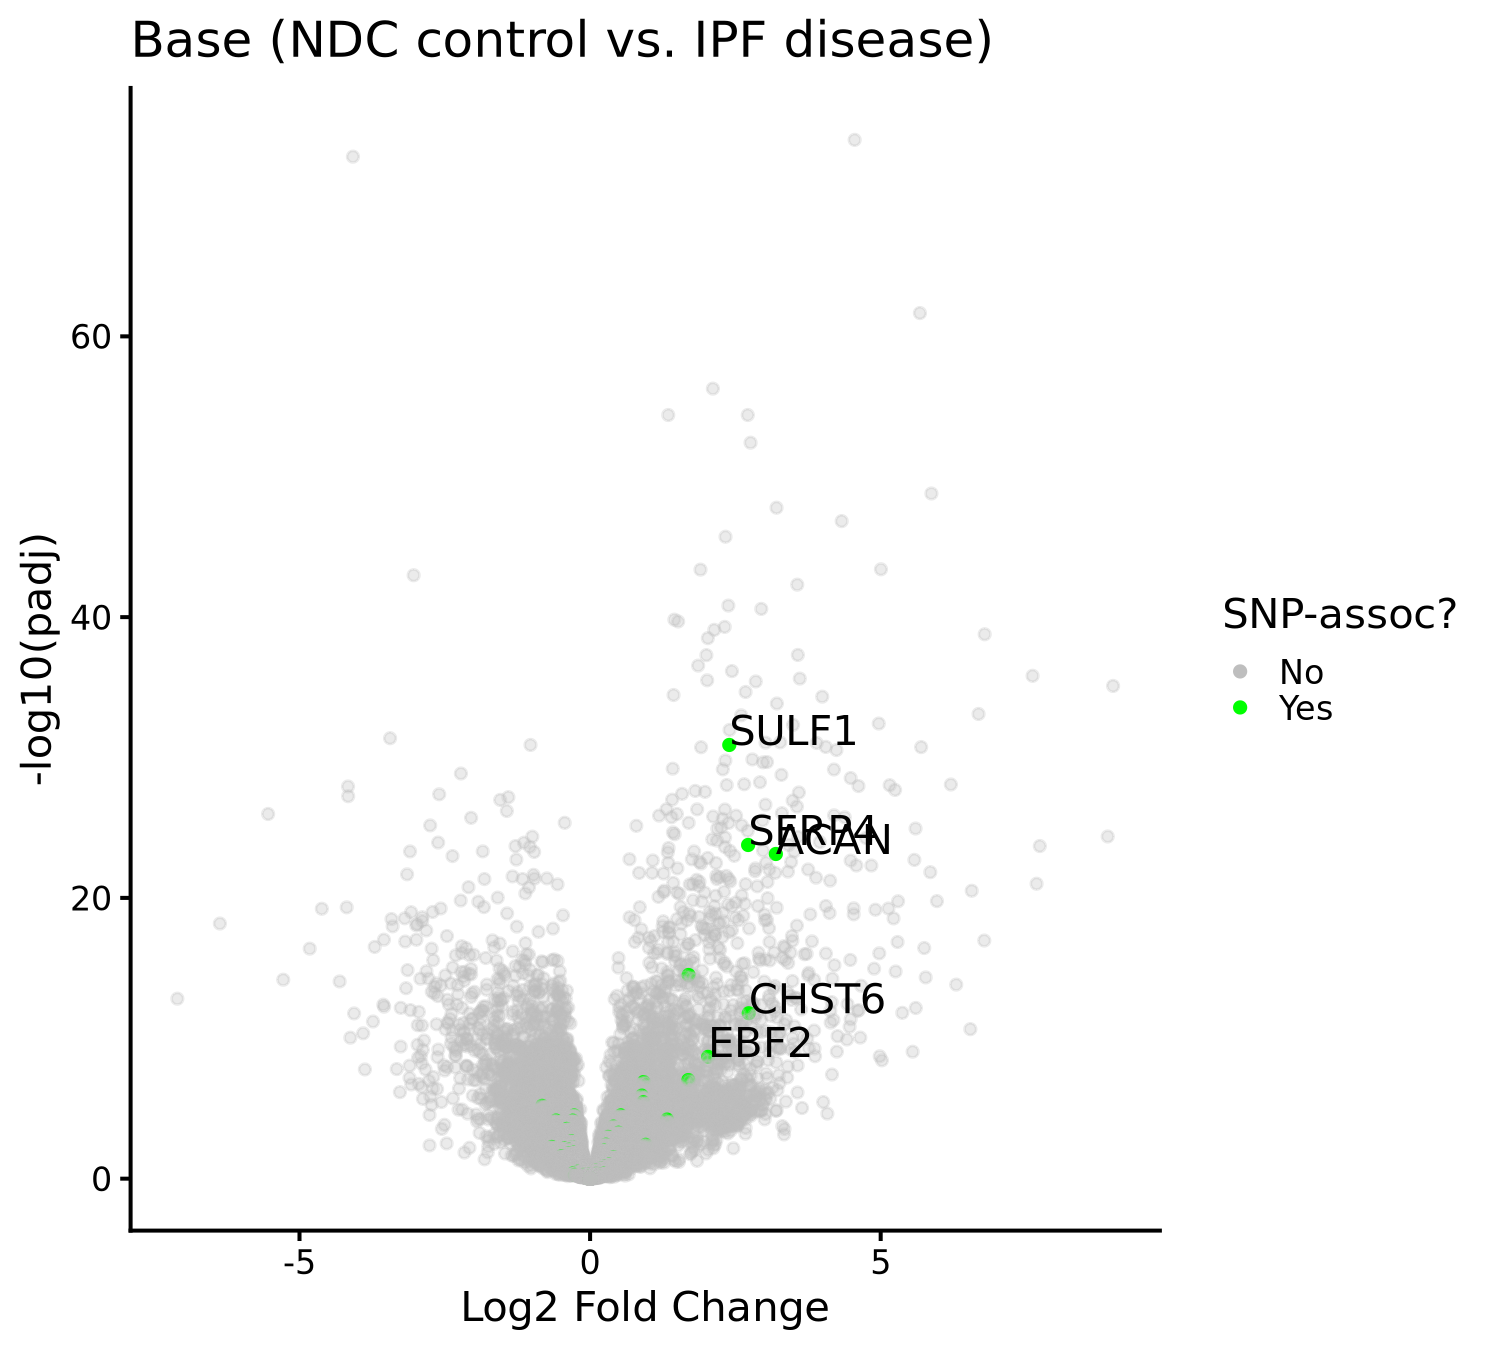

In [47]:
# All IPF base DEGs
ggplot(base, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = case_when(
      padj < 0.05 & log2FoldChange > 2  ~ "Up",
      padj < 0.05 & log2FoldChange < -2 ~ "Down",
      TRUE ~ "NS")),
           alpha=0.7, size=2) +
scale_color_manual(values = c(
"Up" = "red",
"Down" = "blue",
TRUE ~ "NS")) +
theme_classic(base_size = 20) +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="Category", title="Base (NDC control vs. IPF disease)")

dim(base)
dim(filter(base, padj<0.05, abs(log2FoldChange)>2)) #number of IPF base DEGs

# Volcano plot colored by DD SNP-associated genes
ggplot(base, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = ifelse(V1 %in% snps$`Gene Name`, "Yes", "No"), #color point green if SNP-associated
    alpha = ifelse(V1 %in% snps$`Gene Name`, 1, 0.3)), size = 2) +
scale_color_manual(values = c("Yes" = "green", "No" = "gray")) +
scale_alpha_identity() +
geom_text(aes(label = ifelse( #add label to point if DEG and SNP-associated
    V1 %in% snps$`Gene Name` &
    padj < 0.05 &
    abs(log2FoldChange) > 2,
    as.character(V1),"")), hjust=0, vjust=0) +
theme_classic(base_size = 20) +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="SNP-assoc?", title="Base (NDC control vs. IPF disease)")

### Supplementary: DEGs by tissue region (IPF apex vs. IPF base, and NDC apex vs NDC base)

[1] 15012     8

[1] 155   8

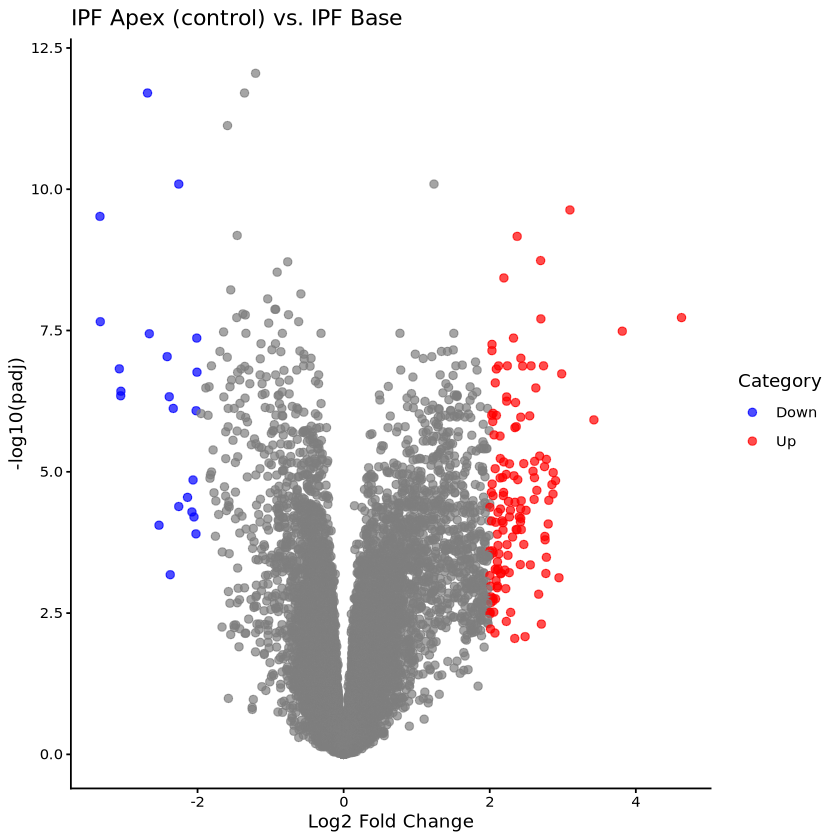

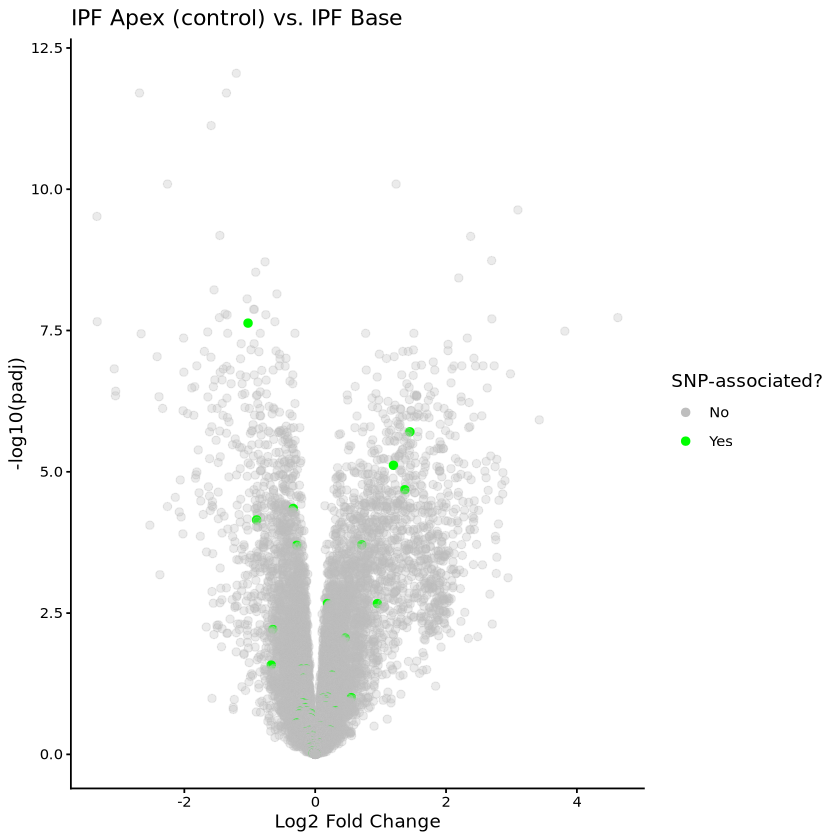

In [12]:
ggplot(diseaseregion, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = case_when(
      padj < 0.05 & log2FoldChange > 2  ~ "Up",
      padj < 0.05 & log2FoldChange < -2 ~ "Down",
      TRUE ~ "NS")),
           alpha=0.7, size=2) +
scale_color_manual(values = c(
"Up" = "red",
"Down" = "blue",
TRUE ~ "NS")) +
theme_classic() +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="Category", title="IPF Apex (control) vs. IPF Base")

dim(diseaseregion)
dim(filter(diseaseregion, padj<0.05, abs(log2FoldChange)>2))

ggplot(diseaseregion, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = ifelse(V1 %in% snps$`Gene Name`, "Yes", "No"),
    alpha = ifelse(V1 %in% snps$`Gene Name`, 1, 0.3)), size = 2) +
scale_color_manual(values = c("Yes" = "green", "No" = "gray")) +
scale_alpha_identity() +
geom_text(aes(label = ifelse(
    V1 %in% snps$`Gene Name` &
    padj < 0.05 &
    abs(log2FoldChange) > 2,
    as.character(V1),"")), hjust=0, vjust=0) +
theme_classic() +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="SNP-associated?", title="IPF Apex (control) vs. IPF Base")

[1] 15012     8

[1] 27  8

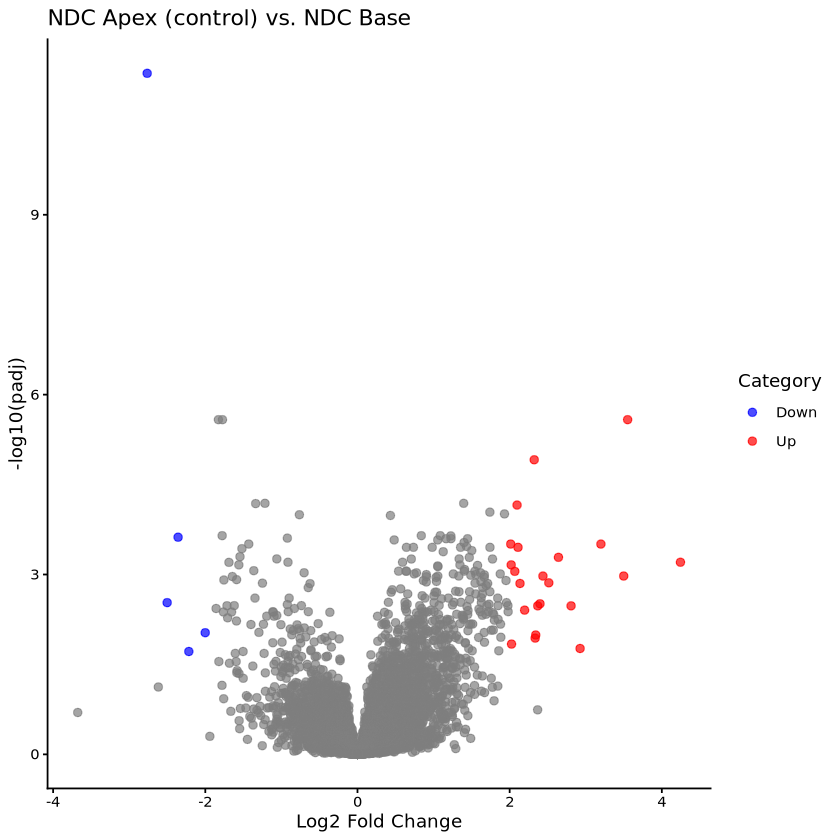

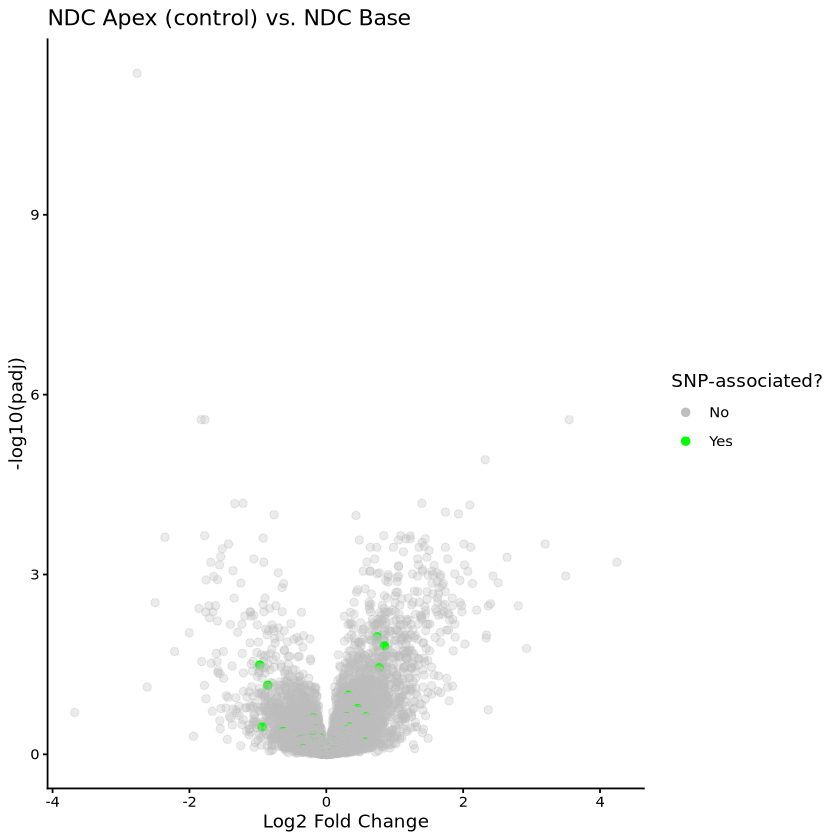

In [13]:
ggplot(healthyregion, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = case_when(
      padj < 0.05 & log2FoldChange > 2  ~ "Up",
      padj < 0.05 & log2FoldChange < -2 ~ "Down",
      TRUE ~ "NS")),
           alpha=0.7, size=2) +
scale_color_manual(values = c(
"Up" = "red",
"Down" = "blue",
TRUE ~ "NS")) +
theme_classic() +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="Category", title="NDC Apex (control) vs. NDC Base")

dim(healthyregion)
dim(filter(healthyregion, padj<0.05, abs(log2FoldChange)>2))

ggplot(healthyregion, mapping = aes(x = log2FoldChange, y = -log10(padj))) +
geom_point(aes(color = ifelse(V1 %in% snps$`Gene Name`, "Yes", "No"),
    alpha = ifelse(V1 %in% snps$`Gene Name`, 1, 0.3)), size = 2) +
scale_color_manual(values = c("Yes" = "green", "No" = "gray")) +
scale_alpha_identity() +
geom_text(aes(label = ifelse(
    V1 %in% snps$`Gene Name` &
    padj < 0.05 &
    abs(log2FoldChange) > 2,
    as.character(V1),"")), hjust=0, vjust=0) +
theme_classic() +
labs(x = "Log2 Fold Change", y="-log10(padj)", color="SNP-associated?", title="NDC Apex (control) vs. NDC Base")

### Dot Plot

In [27]:
# load raw counts and metadata
meta <- fread("GSE213001_filtered_metadata.txt")
setnames(meta, "V1", "SampleID")
counts <- fread("GSE213001_Entrez-IDs-Lung-IPF-GRCh38-p12-raw_counts.csv")

head(meta)
head(counts)

SampleID,!Sample_source_name_ch1,!Sample_organism_ch1,tissue,donorid,group,lib.size,norm.factors,lunglocation,leftright,⋯,processingdate,diseasesubtype,smokingstatus,severity,fvcprebd perc,dlco perc,dlco perc_corrected,diseasegroup1,age group,!Sample_molecule_ch1
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
ALF008C,"Lung,IPF.Apex,Whole lung",Homo sapiens,Whole lung,ALF008,IPF.Apex,15573259,1.0085630,Apex,Right,⋯,5/1/2018,IPF,Ex-Smoker,Severe,43,36,NA,IPF,Senior Adult (>=60),polyA RNA
ALF013B,"Lung,NDC.Base,Whole lung",Homo sapiens,Whole lung,ALF013,NDC.Base,14146498,1.0259452,Base,Unclassified,⋯,5/1/2018,NDC,Ex-Smoker,Unknown,NA,NA,NA,NDC,Adult [19-59],polyA RNA
ALF019A,"Lung,IPF.Apex,Whole lung",Homo sapiens,Whole lung,ALF019,IPF.Apex,11850218,0.9857860,Apex,Left,⋯,5/1/2018,IPF,Never,Advanced,47,16,NA,IPF,Adult [19-59],polyA RNA
ALF030A,"Lung,NDC.Apex,Whole lung",Homo sapiens,Whole lung,ALF030,NDC.Apex,11836796,0.9922272,Apex,Left,⋯,5/2/2018,NDC,Unknown,Unknown,NA,NA,NA,NDC,Adult [19-59],polyA RNA
ALF040B,"Lung,IPF.Base,Whole lung",Homo sapiens,Whole lung,ALF040,IPF.Base,13232206,1.1445373,Base,Right,⋯,5/8/2018,IPF,Never,Severe,39,NA,NA,IPF,Senior Adult (>=60),polyA RNA
ALF020A,"Lung,NDC.Apex,Whole lung",Homo sapiens,Whole lung,ALF020,NDC.Apex,13188455,0.9871568,Apex,Right,⋯,5/2/2018,NDC,Ex-Smoker,Unknown,NA,NA,NA,NDC,Adult [19-59],polyA RNA


V1,ALF001,ALF004C,ALF004D,ALF007A,ALF007B,ALF007C,ALF007D,ALF008A,ALF008B,⋯,ALF048A,ALF048B,ALF048C,ALF048D,ALF049A,ALF049B,ALF050A,ALF050B,ALF050C,ALF050D
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000279457,21,39,62,42,32,28,17,21,27,⋯,40,36,45,36,27,41,57,52,57,49
ENSG00000187634,287,379,383,313,188,402,158,413,777,⋯,71,46,33,253,60,111,42,18,23,28
ENSG00000188976,484,679,769,727,627,686,685,610,629,⋯,602,529,638,668,766,758,671,703,766,703
ENSG00000187961,66,228,230,198,113,181,75,156,186,⋯,98,138,147,87,142,152,237,183,264,195
ENSG00000187583,18,47,65,25,23,35,11,68,35,⋯,19,31,30,11,17,9,24,25,18,22
ENSG00000188290,142,173,216,181,168,179,264,106,250,⋯,143,194,150,206,180,121,224,139,140,94


In [28]:
# will be splitting by disease and tissue region: print out # of samples in each
unique(meta$group)
length(meta$group == 'IPF.Apex')
length(meta$group == 'IPF.Base')

length(meta$group == 'NDC.Apex')
length(meta$group == 'NDC.Base')

[1] "IPF.Apex" "NDC.Base" "NDC.Apex" "IPF.Base" "IPF.NA"   "NDC.NA"

[1] 103

[1] 103

[1] 103

[1] 103

In [29]:
# Convert ensemb IDs to common gene symbols
geneIDs <- counts$V1
counts <- as.data.frame(counts)

gene_map <- setNames(
  emap$`Gene name`,
  emap$`Gene stable ID`
)

symbols <- gene_map[geneIDs]
symbols <- unname(symbols)

counts$V1 <- symbols

counts_collapsed <- counts %>%
  filter(!is.na(V1), V1 != "") %>%
  group_by(V1) %>%
  summarise(across(everything(), sum), .groups = "drop")

counts_collapsed <- counts_collapsed %>%
  tibble::column_to_rownames("V1")

head(counts_collapsed)
anyDuplicated(rownames(counts_collapsed))

,ALF001,ALF004C,ALF004D,ALF007A,ALF007B,ALF007C,ALF007D,ALF008A,ALF008B,ALF008C,⋯,ALF048A,ALF048B,ALF048C,ALF048D,ALF049A,ALF049B,ALF050A,ALF050B,ALF050C,ALF050D
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
A2M,165871,80249,75169,181382,170068,142520,50222,162937,201332,195201,⋯,55966,66348,54162,43246,121380,118318,98106,83022,87190,97983
A4GALT,520,314,402,461,707,549,605,349,420,530,⋯,198,216,325,407,399,263,275,250,251,240
AAAS,340,575,709,556,495,615,304,445,529,512,⋯,320,380,426,216,499,671,505,500,578,515
AACS,181,400,493,232,345,218,622,231,279,333,⋯,244,235,253,438,293,372,406,370,391,371
AADAC,51,47,61,36,74,20,569,49,54,9,⋯,50,9,36,233,25,87,36,42,26,26
AADAT,64,124,99,83,67,66,50,80,129,159,⋯,52,48,64,55,94,130,103,114,122,97


[1] 0

In [30]:
# Library sizes
lib_sizes <- colSums(counts_collapsed)

# CPM normalization
cpm <- sweep(
  counts_collapsed,
  2,
  lib_sizes,
  FUN = "/"
) * 1e6

# log2 CPM
logCPM <- log2(cpm + 1)

dim(logCPM)
head(logCPM[,1:5])

[1] 15012   139

,ALF001,ALF004C,ALF004D,ALF007A,ALF007B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,13.741500,12.678287,12.610140,13.742384,13.611310
A4GALT,5.457277,4.735683,5.105632,5.163069,5.728479
AAAS,4.861581,5.583690,5.905964,5.426490,5.225804
AACS,3.994983,5.073230,5.392269,4.211634,4.721638
AADAC,2.381524,2.274494,2.602373,1.895248,2.688150
AADAT,2.651735,3.475931,3.206797,2.862112,2.567986


In [31]:
#subset to genes of interest (statistically significant and conserved across both fibrotic diseases)
snpDEGs <- c("SULF1", "SFRP4", "ACAN", "CHST6", "EBF2")

expr <- logCPM[snpDEGs, ]

In [32]:
expr_long <- expr %>%
  as.data.frame() %>%
  rownames_to_column("Gene") %>%
  pivot_longer(
    cols = -Gene,
    names_to = "SampleID",
    values_to = "logCPM"
  ) %>%
  left_join(meta, by = "SampleID")

expr_long <- filter(expr_long, group %in% c("IPF.Apex", "IPF.Base", "NDC.Apex", "NDC.Base"))

In [33]:
dot_data <- expr_long %>%
  group_by(Gene, group) %>%
  summarise(
    MeanExpr = mean(logCPM),
    PercentExpressed = mean(logCPM > 1) * 100,
    .groups = "drop"
  )

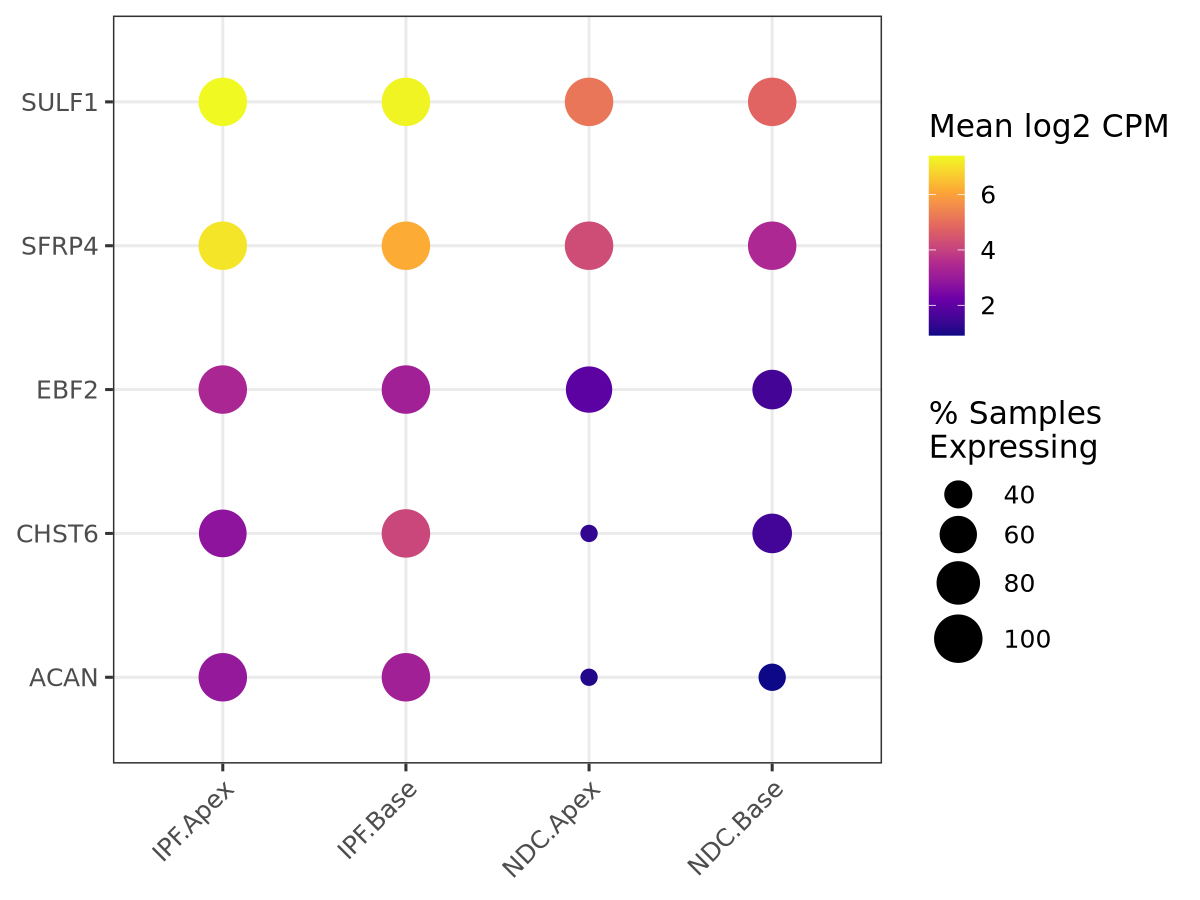

In [41]:
# dot plot: represent average expression (in log2CPM) and number of samples expressing
plot_size(wid = 8, hei = 6)
ggplot(
  dot_data,
  aes(
    x = group,
    y = Gene,
    color = MeanExpr,
    size = PercentExpressed
  )
) +
  geom_point() +
  scale_color_viridis_c(
    option = "plasma"
  ) +
  scale_size(
    range = c(3,10)
  ) +
  theme_bw(base_size = 15) +
  labs(
    x = NULL,
    y = NULL,
    color = "Mean log2 CPM",
    size = "% Samples\nExpressing"
  ) +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    ),
    panel.grid.minor = element_blank()
  )

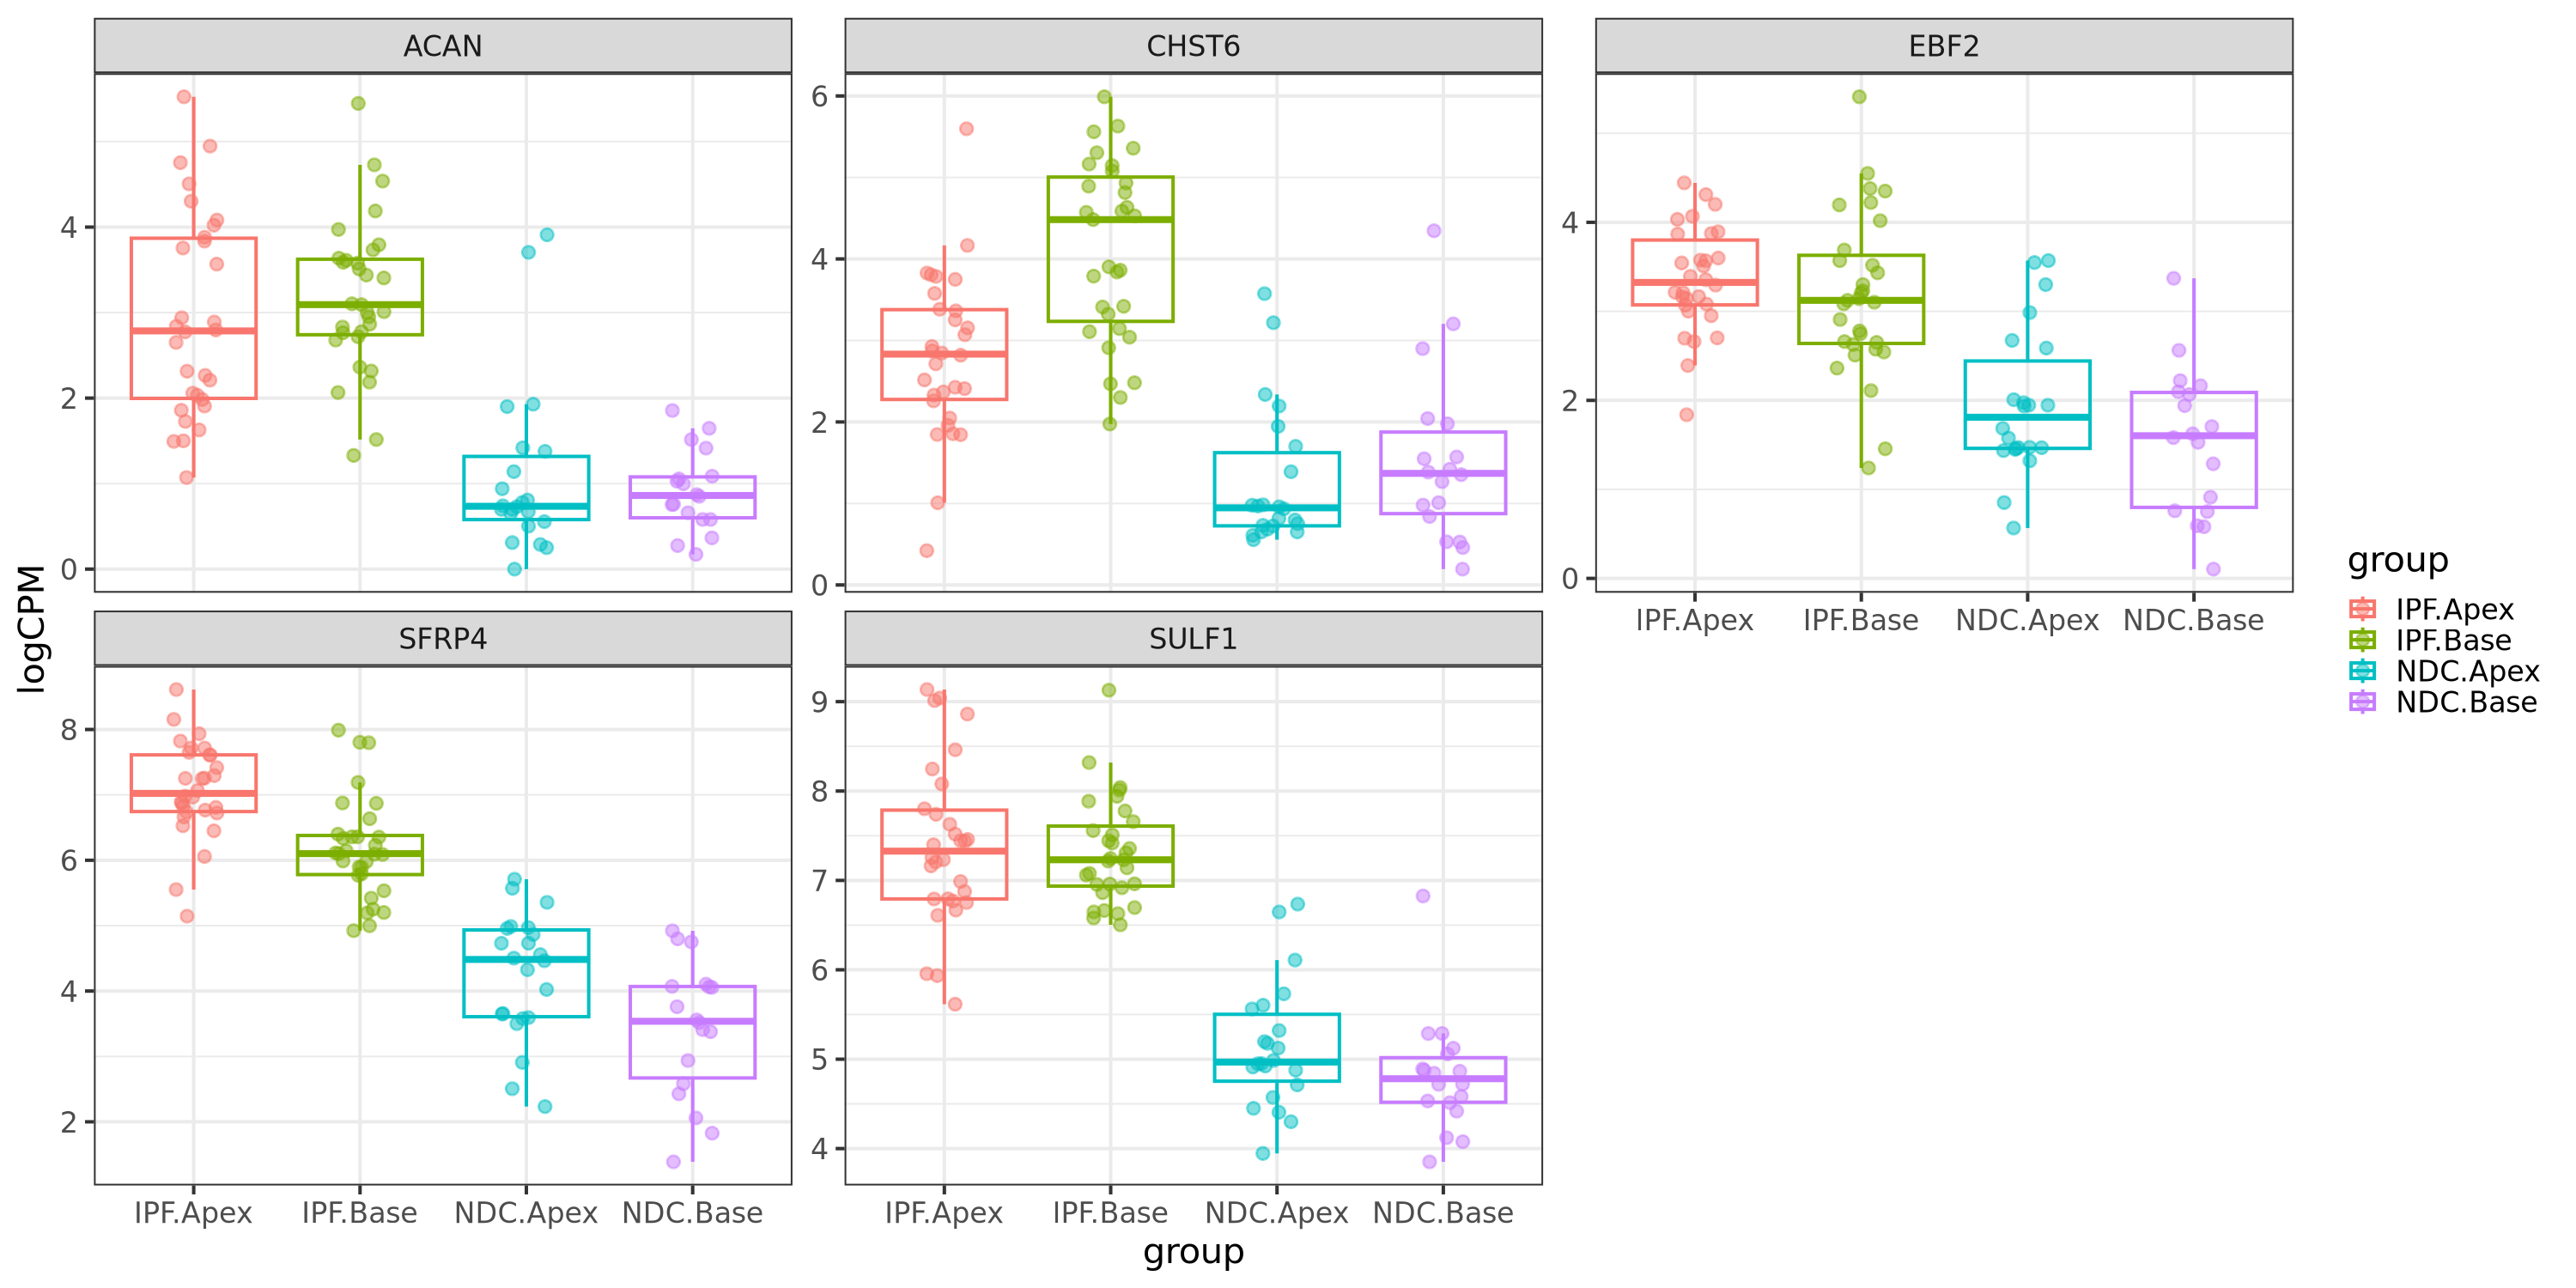

In [40]:
# supplementary plot: logCPM-normalized expression of genes of interest in IPF, across groups (IPF/NDC apex/base)
plot_size(wid = 20, hei = 10)
ggplot(
  expr_long,
  aes(
    x = group,
    y = logCPM,
    color = group
  )
) +
  geom_jitter(
    width = 0.15,
    alpha = 0.5
  ) +
  geom_boxplot(
    alpha = 0,
    outlier.shape = NA
  ) +
  facet_wrap(~Gene, scales = "free_y") +
  theme_bw(base_size = 20)